In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [97]:
data = pd.read_csv("/Users/mariahloehr/IICD/IICD/LOCO/iLOCO/iloco_decisionTree.csv")
df = pd.DataFrame(data)

In [98]:
import re

def rename_feature(name):
    # Pattern for matching each feature of the form Protein..loc.metric.
    pattern = r"(\w+)\.\.(nuc|cyto|PN|PM|cell)\.\w+\."

    def repl(match):
        protein, location = match.groups()
        location_map = {
            'nuc': 'nuc',
            'cyto': 'cyto',
            'PN': 'PN',
            'PM': 'PM',
            'cell': 'cell'
        }
        location_full = location_map.get(location, location)
        return f"{protein} ({location_full})"

    # Apply substitution to all matching parts of the string
    return re.sub(pattern, repl, name)

# Apply renaming
renamed_features = [rename_feature(col) for col in df["feature"]]

In [99]:
df["feature"] = renamed_features
top_20 = df.nlargest(10, "scores")
top_20.replace('p21 (nuc) & p38..phospho.total.PN.', 'p21 (nuc) & p38 phospho (PN)', inplace=True)
top_20.replace('ERK..phospho.total.cyto. & cycD1_over_p21', 'ERK phospho (cyto) & cycD1:p21', inplace=True)
top_20.replace('cFos (PM) & p38..phospho.total.PN.', 'cFos (PM) & p38 phospho (PN)', inplace=True)
top_20.replace('YAP (PN) & RB..phospho.total.cell.', 'YAP (PN) & RB phospho (cell)', inplace=True)

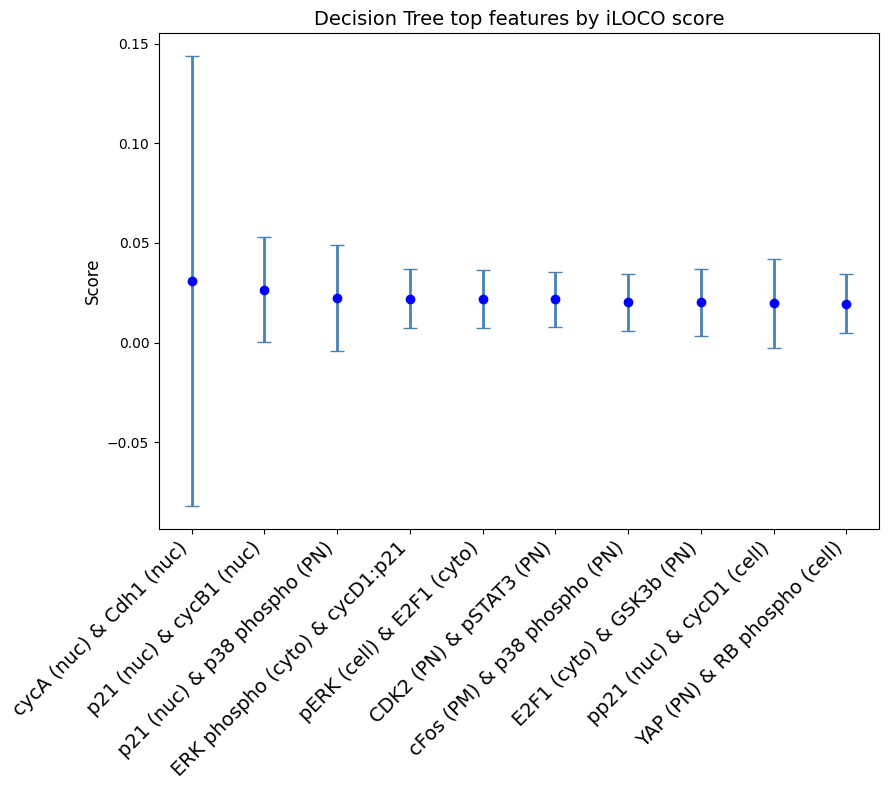

In [100]:
# Plot
plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20["feature"],
    top_20["scores"],
    yerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.xticks(rotation=45, fontsize=14, ha = "right")  # Rotate x-axis labels vertically
plt.ylabel("Score", fontsize=12)
plt.title("Decision Tree top features by iLOCO score", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()

In [79]:
xgb_data = pd.read_csv("/Users/mariahloehr/IICD/IICD/LOCO/iLOCO/iloco_xgb.csv")
xgb_df = pd.DataFrame(xgb_data)

In [80]:
import re

def rename_feature(name):
    # Pattern for matching each feature of the form Protein..loc.metric.
    pattern = r"(\w+)\.\.(nuc|cyto|PN|PM|cell)\.\w+\."

    def repl(match):
        protein, location = match.groups()
        location_map = {
            'nuc': 'nuc',
            'cyto': 'cyto',
            'PN': 'PN',
            'PM': 'PM',
            'cell': 'cell'
        }
        location_full = location_map.get(location, location)
        return f"{protein} ({location_full})"

    # Apply substitution to all matching parts of the string
    return re.sub(pattern, repl, name)

#def rename_feature(name):
#    match = re.match(r"(\w+)\.\.(nuc|cyto)\.\w+\.", name)
#    if match:
#        protein, location = match.groups()
#        location_full = 'nucleus' if location == 'nuc' else 'cytoplasm'
#       return f"{protein} ({location_full})"
#    return name  # leave unchanged if it doesn't match the pattern

# Apply renaming
renamed_features = [rename_feature(col) for col in xgb_df["feature"]]

In [83]:
xgb_df["feature"] = renamed_features
top_20_xgb = xgb_df.nlargest(10, "scores")
top_20_xgb.replace('Cdh1 (PM) & p21..phospho.total.cell.', 'Cdh1 (PM) & p21 phospho (cell)', inplace=True)
top_20_xgb.replace('cycA (PN) & GSK3b..phospho.total.cyto.', 'Cdh1 (PM) & GSK3b phospho (cyto)', inplace=True)
top_20_xgb.replace('Int_Intg_DNA_nuc & YAP (cell)', 'DNA (nuc) & YAP (cell)', inplace=True)

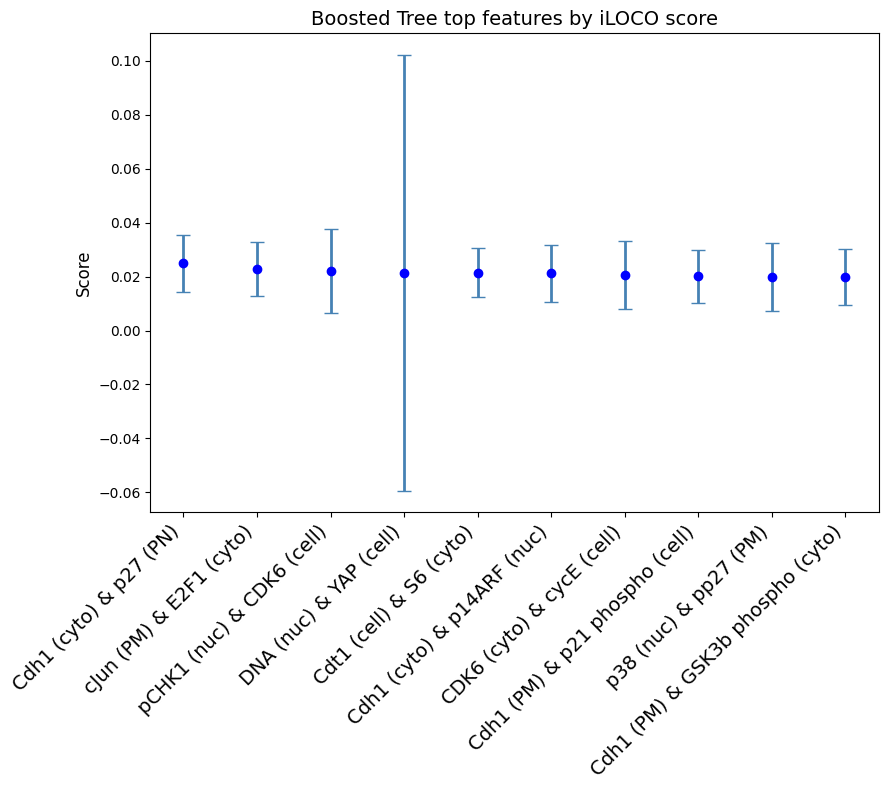

In [86]:
# Plot
plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20_xgb["feature"],
    top_20_xgb["scores"],
    yerr=top_20_xgb["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.xticks(rotation=45, fontsize=14, ha = "right")  # Rotate x-axis labels vertically
plt.ylabel("Score", fontsize=12)
plt.title("Boosted Tree top features by iLOCO score", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()